<a href="https://colab.research.google.com/github/snig-17/COMP0014/blob/main/COMP0014_Final_Coursework_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task C: Alternative Kernel Exploration



Project C: answer the following questions:

1) Which kernel will you use? How do you predict it will perform? Train a model using this
kernel.
2) How does the model with the kernel you selected perform? Consider what metric(s) you
want to use to measure performance. Present the metric(s) collected and compare it to a
baseline (e.g. data points without transformation).
3) Summarize the results you got and their meaning.

# Question 1

## Which kernel will we use?

### Linear Kernel

Formula: K(xᵢ, xⱼ) = xᵢ · xⱼ

The linear kernel computes the dot product between two input vectors to produce a linear decision boundary directly in the original feature space. It is the simplest function; typically used in applications where data points are already separable, such as in text classification (Riswanto, 2025). This is because linear kernel functions cannot capture non-linear patterns.
However, there are significant positive tradeoffs that make this a widely used kernel. It is less prone to over-fitting, and less sensitive to hyperparameter tuning (only the regularisation parameter needs optimisation, which applies to all kernels).

### Polynomial Kernel

Formula: K(xᵢ, xⱼ) = (γ · xᵢ · xⱼ + r)^d

For datasets with higher degree relationships, polynomial kernel functions are suitable  (Riswanto, 2025). This function maps input data into a higher-dimensional space using a polynomial function. Despite the additional computational cost, complex datasets require the extraction of higher degree relationships for accurate classification  (Riswanto, 2025).
In terms of kernel parameters, the complexity of this kernel is determined by the degree (d) of the polynomial. In the formula, gamma (γ) determines the impact individual training points have on the decision boundary (scikit-learn, 2025). In other words, it behaves as a scaling factor, where a larger γ amplifies the dot product between two data points, whilst a smaller γ reduces sensitivity to individual point relationships. The bias term (r) shifts the decision boundary and determines the influence of higher-degree versus lower-degree terms (scikit-learn, 2025). If r=0, the kernel becomes a homogeneous polynomial, which constrains the boundary to pass through the origin. Conversely, if r>0, the kernel becomes inhomogeneous, giving the decision boundary more flexibility rather than being anchored at the origin.
Unlike the linear kernel, the polynomial kernel function has significantly more parameters. Hence, a limitation of this function is that classification accuracy is dependent on the suitability of parameter selection (Ding et al, 2021).

### RBF Kernel

Formula: K(xᵢ, xⱼ) = exp(−γ · ||xᵢ − xⱼ||²)

RBF kernels are the most widely used kernel functions because they can handle a wide range of complex data. In datasets with overlapping classes, irregular patterns, or if the relationship in the data is unknown, the RBF kernel function is suitable (Riswnato, 2025).
This kernel can handle such complexity because it maps data into an infinite-dimensional space (Starmer, 2019).
The function computes the squared Euclidean distance, ||xᵢ − xⱼ||²between two points to determine the similarity between them. This value is contained inside an exponential decay function, which leads to a kernel output value that approaches 0 as the distance between the points increases.
Similar to the polynomial kernel, the parameter γ is used in RBF. A large value for γ means only nearby points influence each other, while a low value for γ leads to a smoother boundary (scikit-learn, 2025). Unlike the polynomial kernel, which is a global function (distant points can influence the decision boundary), RBF is a local kernel. Only points determined by γ meaningfully influence each other.
Although this is the default kernel choice for non-linear problems, it also comes with disadvantages such as its computational cost and hyperparameter (γ) sensitivity.

### Sigmoid Kernel

Formula: K(xᵢ, xⱼ) = tanh(α · xᵢ · xⱼ + β)

Despite being less commonly used, the sigmoid kernel function is included in this analysis due to its unique ability to mimic the behaviour of a single-layer neural network (Lin and Lin, 2003). Due to this property, its main application is for modelling data with “neural-like distributions” (GeeksforGeeks, 2020). The sigmoid kernel implements the hyperbolic tangent function to calculate the similarity between two points (scikit-learn, 2025). The parameter α is computed identically to the parameter γ in the polynomial and RBF kernel, and serves as a scaling parameter for the slope of the tanh function (GeeksforGeeks, 2020). Likewise, β, the parameter, behaves like the bias term r, shifting the tanh function accordingly (GeeksforGeeks, 2020). In addition to the previously outlined limitations of parameter sensitivity, the sigmoid kernel function also doesn’t guarantee validity (does not satisfy Mercer's condition) for certain parameter settings (Vasileios Apostolidis-Afentoulis, 2015). Despite this, it is included as a theoretically interesting comparative case.

## How do you predict it will perform?

### Hypothesis

Based on the mathematical properties of each kernel function alongside empirical literature by Ding et al. (2021), we hypothesise the following ranked performance for the Fashion MNIST dataset:
1. RBF
2. Polynomial
3. Linear
4. Sigmoid   

Non-linear kernels operating in a higher-dimensional space will produce more tractable class boundaries (Vasileios Apostolidis-Afentoulis, 2015). In particular, RBF is hypothesised to have the best performance based on its fundamental properties alongside strong empirical performance in multi-class datasets (Ding et al., 2021; Chalasani, 2023). Polynomial is expected to outperform linear due to its improved feature extraction capability in non-linear data. However, its global kernel nature is expected to limit its performance relative to RBF on classes with fine-grained class distinctions, such as Shirt versus T-shirt/top (Ding et al., 2021). Sigmoid is expected to perform the worst, given its high parameter sensitivity and poor generalizability (scikit-learn, 2025).

## Training our models using these kernels

### Hyperparameter Optimisation

#### C parameter justification

C=0.1, 1, 10  represents a 1 order of magnitude range around the scikit-learn default (C=1).

#### Degree parameter justification

Degree 3 and 4 was found optimal for Fashion MNIST and used in literature previously (Jalasutram, 2021).

#### Gamma parameter justification

In sci-kit learn's SVM implementation the
```
gamma = 'scale'
```
option uses

gamma = 1/n_features x X.var()





| Kernel Function      | C | Gamma | Degree |
| ----------- | ----------- |-----------|-----------|
| Linear      | 0.1, 1, 10       |N/A|N/A
| Polynomial   | 0.1, 1, 10          |Scale|3, 4
| RBF      | 0.1, 1, 10        |Scale|N/A
| Sigmoid   | 0.1, 1, 10         |Scale|N/A

### Consolidate Setup and Preprocessing



In [1]:
import numpy as np
import struct
from array import array
import os.path
import random
import matplotlib.pyplot as plt
import time
import datetime
from sklearn import svm, metrics
from sklearn.model_selection import train_test_split
import pandas as pd
%matplotlib inline

# Fashion MNIST labels
fashion_labels = {
    0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
    5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'
}

# Data Loader Utility
class MnistDataloader(object):
    def __init__(self, training_images_filepath, training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath

    def read_images_labels(self, images_filepath, labels_filepath):
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            labels = np.array(array("B", file.read()), dtype=np.uint8)
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            image_data = array("B", file.read())
            images = np.array(image_data, dtype=np.uint8).reshape(size, rows * cols)
        return images, labels

    def load_data(self):
        (x_train, y_train) = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        (x_test, y_test) = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train), (x_test, y_test)

# Visualization Utility
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images) / cols) + 1
    plt.figure(figsize=(20, 10))
    for i, (img, title) in enumerate(zip(images, title_texts), 1):
        plt.subplot(rows, cols, i)
        plt.imshow(img.reshape(28, 28), cmap='gray')
        plt.title(title, fontsize=10)
        plt.axis('off')
    plt.show()

# Best Result Utility
def get_best(results):
    return max(results, key=lambda x: x['test_acc'])

# Load Dataset
input_path = '/content/Fashion_MNIST/'
loader = MnistDataloader(
    os.path.join(input_path, 'train-images-idx3-ubyte'),
    os.path.join(input_path, 'train-labels-idx1-ubyte'),
    os.path.join(input_path, 't10k-images-idx3-ubyte'),
    os.path.join(input_path, 't10k-labels-idx1-ubyte')
)
(x_train, y_train), (x_test, y_test) = loader.load_data()

# Data Preprocessing
# Normalize pixels
x_train = x_train / 255.0
x_test = x_test / 255.0

# Subsample for faster grid search (10% training data)
x_train_mini, _, y_train_mini, _ = train_test_split(x_train, y_train, test_size=0.9, random_state=666)
class_names = list(fashion_labels.values())

print('Setup and preprocessing complete. Training set size:', x_train_mini.shape[0])

Setup and preprocessing complete. Training set size: 6000


In [2]:
import numpy as np
import struct
from array import array
import os.path
import random
import matplotlib.pyplot as plt
import time
import datetime
from sklearn import svm, metrics
from sklearn.model_selection import train_test_split
import pandas as pd
%matplotlib inline

# Fashion MNIST labels
fashion_labels = {
    0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
    5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'
}

# Data Loader Utility
class MnistDataloader(object):
    def __init__(self, training_images_filepath, training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath

    def read_images_labels(self, images_filepath, labels_filepath):
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            labels = np.array(array("B", file.read()), dtype=np.uint8)
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            image_data = array("B", file.read())
            images = np.array(image_data, dtype=np.uint8).reshape(size, rows * cols)
        return images, labels

    def load_data(self):
        (x_train, y_train) = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        (x_test, y_test) = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train), (x_test, y_test)

# Visualization Utility
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images) / cols) + 1
    plt.figure(figsize=(20, 10))
    for i, (img, title) in enumerate(zip(images, title_texts), 1):
        plt.subplot(rows, cols, i)
        plt.imshow(img.reshape(28, 28), cmap='gray')
        plt.title(title, fontsize=10)
        plt.axis('off')
    plt.show()

# Best Result Utility
def get_best(results):
    return max(results, key=lambda x: x['test_acc'])

# Load Dataset
input_path = '/content/Fashion_MNIST/'
loader = MnistDataloader(
    os.path.join(input_path, 'train-images-idx3-ubyte'),
    os.path.join(input_path, 'train-labels-idx1-ubyte'),
    os.path.join(input_path, 't10k-images-idx3-ubyte'),
    os.path.join(input_path, 't10k-labels-idx1-ubyte')
)
(x_train, y_train), (x_test, y_test) = loader.load_data()

# Data Preprocessing
# Normalize pixels
x_train = x_train / 255.0
x_test = x_test / 255.0

# Subsample for faster grid search (10% training data)
x_train_mini, _, y_train_mini, _ = train_test_split(x_train, y_train, test_size=0.9, random_state=666)
class_names = list(fashion_labels.values())

print('Setup and preprocessing complete. Training set size:', x_train_mini.shape[0])

Setup and preprocessing complete. Training set size: 6000


### Linear Kernel Section




Starting grid search for Linear Kernel...
C=0.1: Train Acc=0.9210, Test Acc=0.8403, Time=5.60s
C=1: Train Acc=0.9778, Test Acc=0.8169, Time=3.05s
C=10: Train Acc=0.9987, Test Acc=0.8010, Time=3.88s

Best Linear Configuration: {'C': 0.1, 'train_acc': 0.921, 'test_acc': 0.8403, 'time': 5.597085237503052}

Classification Report for Best Linear SVM:
              precision    recall  f1-score   support

 T-shirt/top       0.76      0.83      0.79      1000
     Trouser       0.98      0.95      0.97      1000
    Pullover       0.73      0.75      0.74      1000
       Dress       0.84      0.83      0.84      1000
        Coat       0.75      0.73      0.74      1000
      Sandal       0.94      0.91      0.92      1000
       Shirt       0.63      0.58      0.60      1000
     Sneaker       0.90      0.93      0.92      1000
         Bag       0.94      0.94      0.94      1000
  Ankle boot       0.94      0.94      0.94      1000

    accuracy                           0.84     10000
  

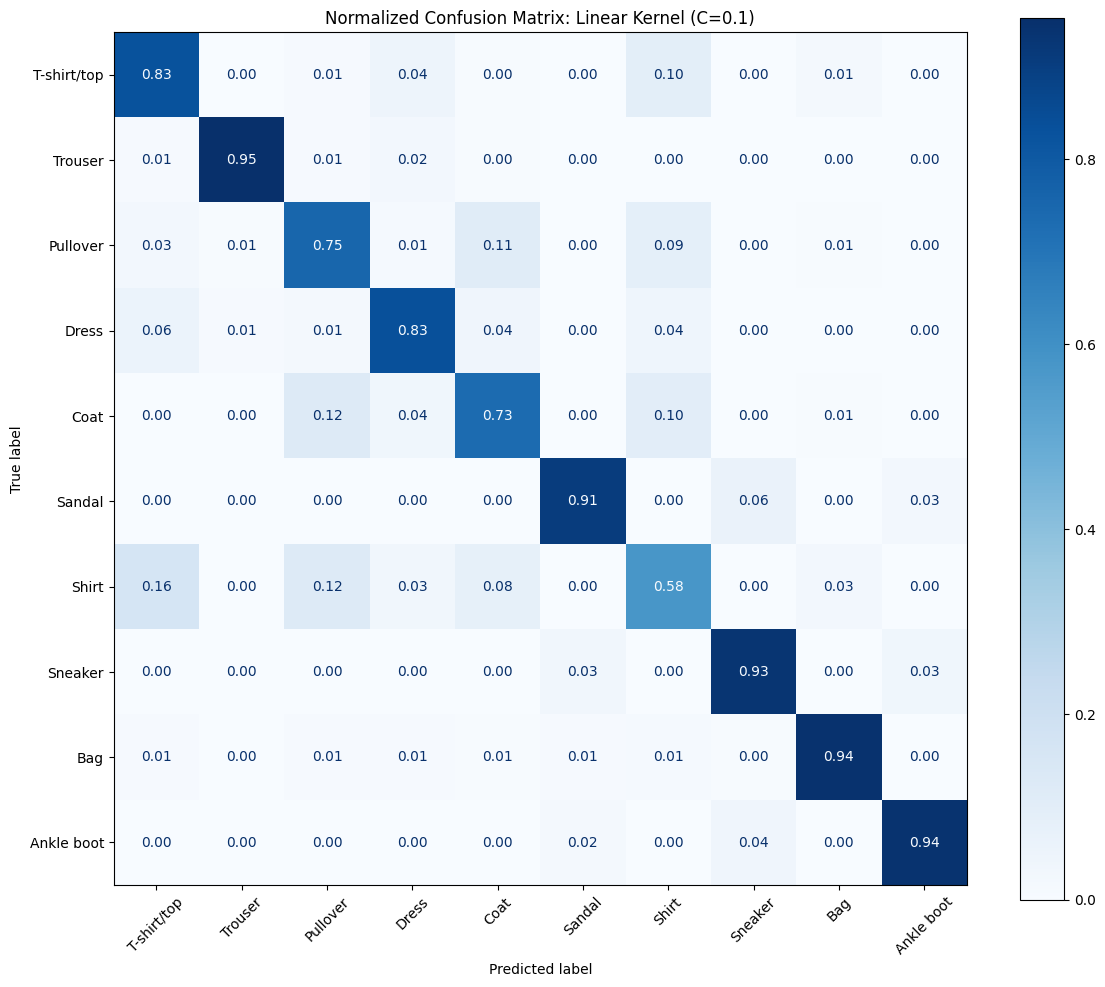

In [3]:
# 1. Initialize results list
linear_results = []
C_values = [0.1, 1, 10]

# 2-5. Grid search for Linear SVM
print('Starting grid search for Linear Kernel...')
for C in C_values:
    clf = svm.SVC(kernel='linear', C=C)
    start_time = time.time()
    clf.fit(x_train_mini, y_train_mini)
    elapsed_time = time.time() - start_time

    train_acc = clf.score(x_train_mini, y_train_mini)
    test_acc = clf.score(x_test, y_test)

    linear_results.append({
        'C': C,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'time': elapsed_time
    })
    print(f'C={C}: Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}, Time={elapsed_time:.2f}s')

# 6. Find the best configuration
best_linear = get_best(linear_results)
print(f'\nBest Linear Configuration: {best_linear}')

# 7. Retrain/Use the best model for final predictions
final_linear_clf = svm.SVC(kernel='linear', C=best_linear['C'])
final_linear_clf.fit(x_train_mini, y_train_mini)
linear_predicted = final_linear_clf.predict(x_test)

# 8. Produce classification report
print('\nClassification Report for Best Linear SVM:')
print(metrics.classification_report(y_test, linear_predicted, target_names=class_names))

# 9. Create and display normalized confusion matrix
cm_linear = metrics.confusion_matrix(y_test, linear_predicted, normalize='true')
fig, ax = plt.subplots(figsize=(12, 10))
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=class_names)
cm_display.plot(values_format='.2f', ax=ax, xticks_rotation=45, cmap='Blues')
plt.title(f'Normalized Confusion Matrix: Linear Kernel (C={best_linear["C"]})')
plt.tight_layout()
plt.show()

### Polynomial Kernel Section



Starting grid search for Polynomial Kernel...
C=0.1, degree=3: Train Acc=0.7677, Test Acc=0.7362, Time=7.24s
C=0.1, degree=4: Train Acc=0.7630, Test Acc=0.7139, Time=5.79s
C=1, degree=3: Train Acc=0.8950, Test Acc=0.8025, Time=4.02s
C=1, degree=4: Train Acc=0.8870, Test Acc=0.7790, Time=4.04s
C=10, degree=3: Train Acc=0.9763, Test Acc=0.8238, Time=2.82s
C=10, degree=4: Train Acc=0.9595, Test Acc=0.8024, Time=3.02s

Best Polynomial Configuration: {'C': 10, 'degree': 3, 'train_acc': 0.9763333333333334, 'test_acc': 0.8238, 'time': 2.821756601333618}

Final Polynomial Test Accuracy: 0.8238

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.75      0.81      0.78      1000
     Trouser       0.98      0.95      0.96      1000
    Pullover       0.71      0.75      0.73      1000
       Dress       0.85      0.78      0.81      1000
        Coat       0.78      0.66      0.72      1000
      Sandal       0.84      0.92      0.87      1000
    

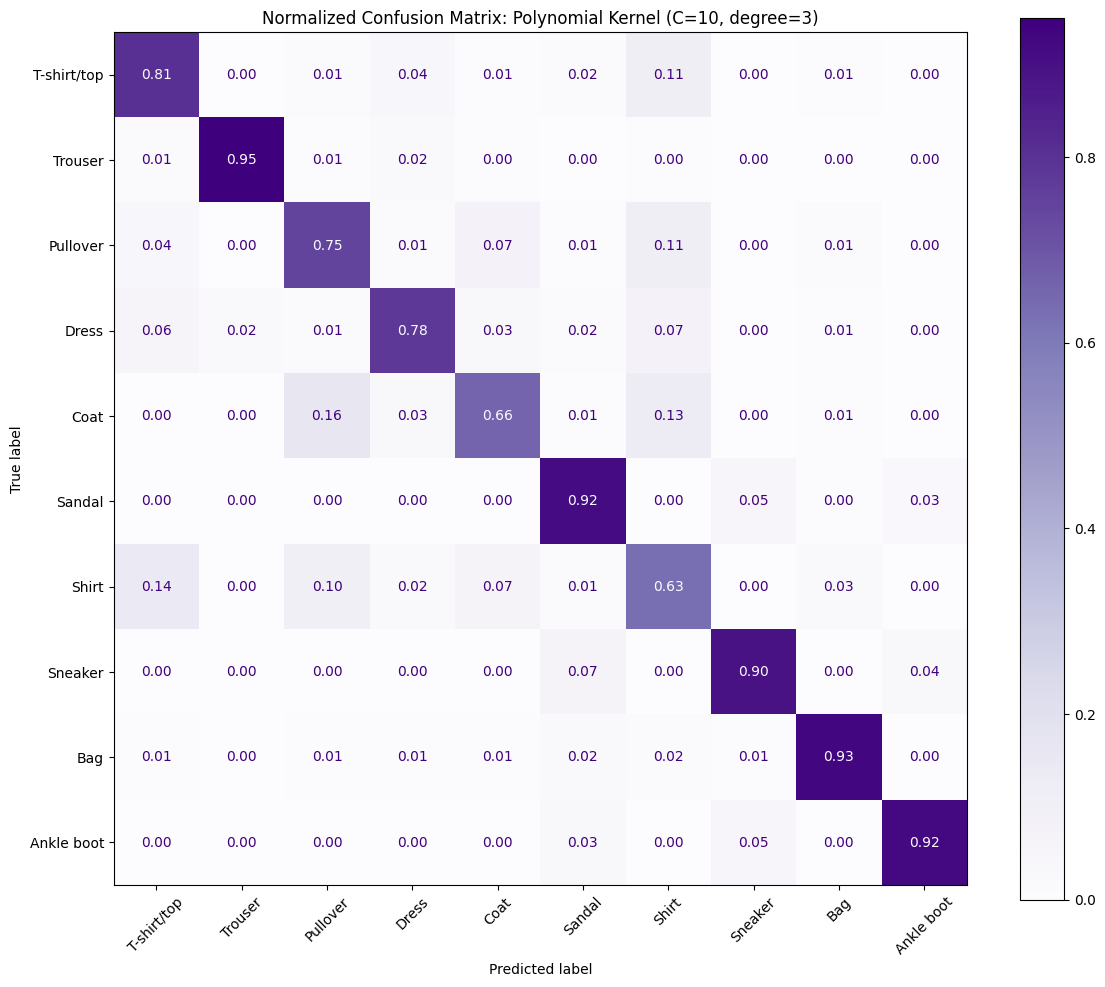

In [4]:
import time
import matplotlib.pyplot as plt
from sklearn import svm, metrics

# 1. Define results list and parameters
poly_results = []
C_values = [0.1, 1, 10]
degrees = [3, 4]

# 2-3. Grid search for Polynomial SVM
print('Starting grid search for Polynomial Kernel...')
for C in C_values:
    for deg in degrees:
        clf = svm.SVC(kernel='poly', C=C, degree=deg, gamma='scale')
        start_time = time.time()
        clf.fit(x_train_mini, y_train_mini)
        elapsed_time = time.time() - start_time

        train_acc = clf.score(x_train_mini, y_train_mini)
        test_acc = clf.score(x_test, y_test)

        poly_results.append({
            'C': C,
            'degree': deg,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'time': elapsed_time
        })
        print(f'C={C}, degree={deg}: Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}, Time={elapsed_time:.2f}s')

# 4. Identify the best configuration
best_poly = get_best(poly_results)
print(f'\nBest Polynomial Configuration: {best_poly}')

# 5. Train final model with optimal parameters
final_poly_clf = svm.SVC(kernel='poly', C=best_poly['C'], degree=best_poly['degree'], gamma='scale')
final_poly_clf.fit(x_train_mini, y_train_mini)
poly_predicted = final_poly_clf.predict(x_test)

# 6. Display test accuracy and classification report
final_test_acc = final_poly_clf.score(x_test, y_test)
print(f'\nFinal Polynomial Test Accuracy: {final_test_acc:.4f}')
print('\nClassification Report:')
print(metrics.classification_report(y_test, poly_predicted, target_names=class_names))

# 7. Generate and plot normalized confusion matrix
cm_poly = metrics.confusion_matrix(y_test, poly_predicted, normalize='true')
fig, ax = plt.subplots(figsize=(12, 10))
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_poly, display_labels=class_names)
cm_display.plot(values_format='.2f', ax=ax, xticks_rotation=45, cmap='Purples')
plt.title(f'Normalized Confusion Matrix: Polynomial Kernel (C={best_poly["C"]}, degree={best_poly["degree"]})')
plt.tight_layout()
plt.show()

### RBF Kernel Section





Starting grid search for RBF Kernel...
C=0.1, gamma=scale: Train Acc=0.7950, Test Acc=0.7777, Time=7.14s
C=0.1, gamma=0.01: Train Acc=0.7947, Test Acc=0.7773, Time=6.26s
C=1, gamma=scale: Train Acc=0.8975, Test Acc=0.8429, Time=3.55s
C=1, gamma=0.01: Train Acc=0.8968, Test Acc=0.8422, Time=3.57s
C=10, gamma=scale: Train Acc=0.9903, Test Acc=0.8618, Time=3.49s
C=10, gamma=0.01: Train Acc=0.9900, Test Acc=0.8616, Time=3.26s

Best RBF Configuration: {'C': 10, 'gamma': 'scale', 'train_acc': 0.9903333333333333, 'test_acc': 0.8618, 'time': 3.4865047931671143}

Classification Report for Best RBF SVM:
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.84      0.82      1000
     Trouser       0.99      0.96      0.97      1000
    Pullover       0.74      0.80      0.77      1000
       Dress       0.87      0.83      0.85      1000
        Coat       0.77      0.77      0.77      1000
      Sandal       0.95      0.93      0.94      1000
       Shirt       0

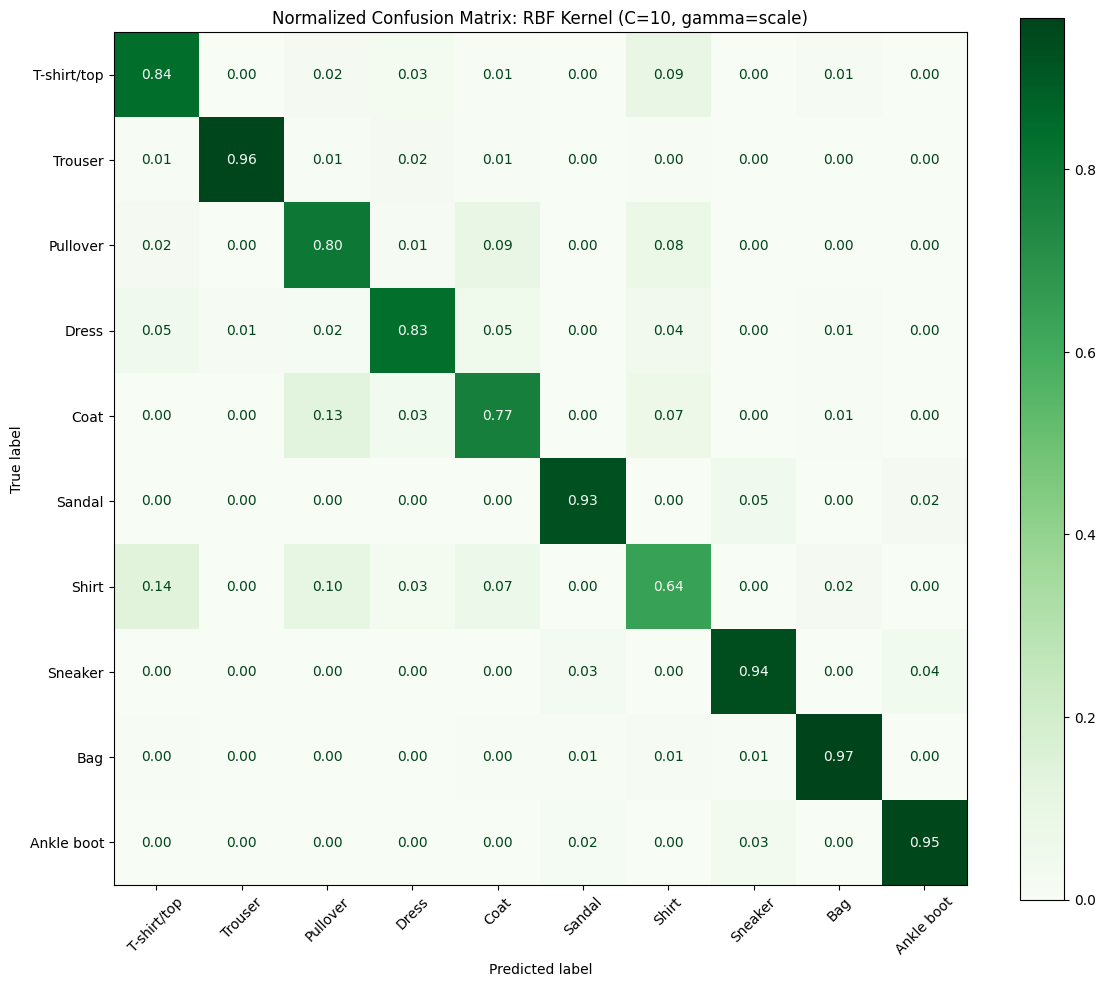

In [5]:
import time
import matplotlib.pyplot as plt
from sklearn import svm, metrics

# 1. Initialize results list
rbf_results = []

# 2. Define grid search parameters
C_values = [0.1, 1, 10]
gamma_values = ['scale', 0.01]

# 3-5. Nested loop for Grid Search
print('Starting grid search for RBF Kernel...')
for C in C_values:
    for gamma in gamma_values:
        clf = svm.SVC(kernel='rbf', C=C, gamma=gamma)
        start_time = time.time()
        clf.fit(x_train_mini, y_train_mini)
        elapsed_time = time.time() - start_time

        train_acc = clf.score(x_train_mini, y_train_mini)
        test_acc = clf.score(x_test, y_test)

        rbf_results.append({
            'C': C,
            'gamma': gamma,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'time': elapsed_time
        })
        print(f'C={C}, gamma={gamma}: Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}, Time={elapsed_time:.2f}s')

# 6. Identify the best configuration
best_rbf = get_best(rbf_results)
print(f'\nBest RBF Configuration: {best_rbf}')

# 7. Train final model with optimal parameters
final_rbf_clf = svm.SVC(kernel='rbf', C=best_rbf['C'], gamma=best_rbf['gamma'])
final_rbf_clf.fit(x_train_mini, y_train_mini)
rbf_predicted = final_rbf_clf.predict(x_test)

# 8. Print detailed classification report
print('\nClassification Report for Best RBF SVM:')
print(metrics.classification_report(y_test, rbf_predicted, target_names=class_names))

# 9. Compute and display normalized confusion matrix
cm_rbf = metrics.confusion_matrix(y_test, rbf_predicted, normalize='true')
fig, ax = plt.subplots(figsize=(12, 10))
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_rbf, display_labels=class_names)
cm_display.plot(values_format='.2f', ax=ax, xticks_rotation=45, cmap='Greens')
plt.title(f'Normalized Confusion Matrix: RBF Kernel (C={best_rbf["C"]}, gamma={best_rbf["gamma"]})')
plt.tight_layout()
plt.show()

### Sigmoid Kernel Section



Starting grid search for Sigmoid Kernel...
C=0.1, coef0=0.5: Train Acc=0.4865, Test Acc=0.4800, Time=18.91s
C=1, coef0=0.5: Train Acc=0.3400, Test Acc=0.3510, Time=7.64s
C=10, coef0=0.5: Train Acc=0.3202, Test Acc=0.3395, Time=7.39s

Best Sigmoid Configuration: {'C': 0.1, 'coef0': 0.5, 'train_acc': 0.4865, 'test_acc': 0.48, 'time': 18.907675743103027}

Final Sigmoid Test Accuracy: 0.4800

Classification Report for Best Sigmoid SVM:
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.36      0.50      1000
     Trouser       0.64      0.89      0.74      1000
    Pullover       0.41      0.28      0.34      1000
       Dress       0.51      0.67      0.58      1000
        Coat       0.15      0.15      0.15      1000
      Sandal       0.23      0.34      0.27      1000
       Shirt       0.21      0.15      0.18      1000
     Sneaker       0.73      0.80      0.76      1000
         Bag       0.70      0.40      0.51      1000
  Ankle boot       0.57

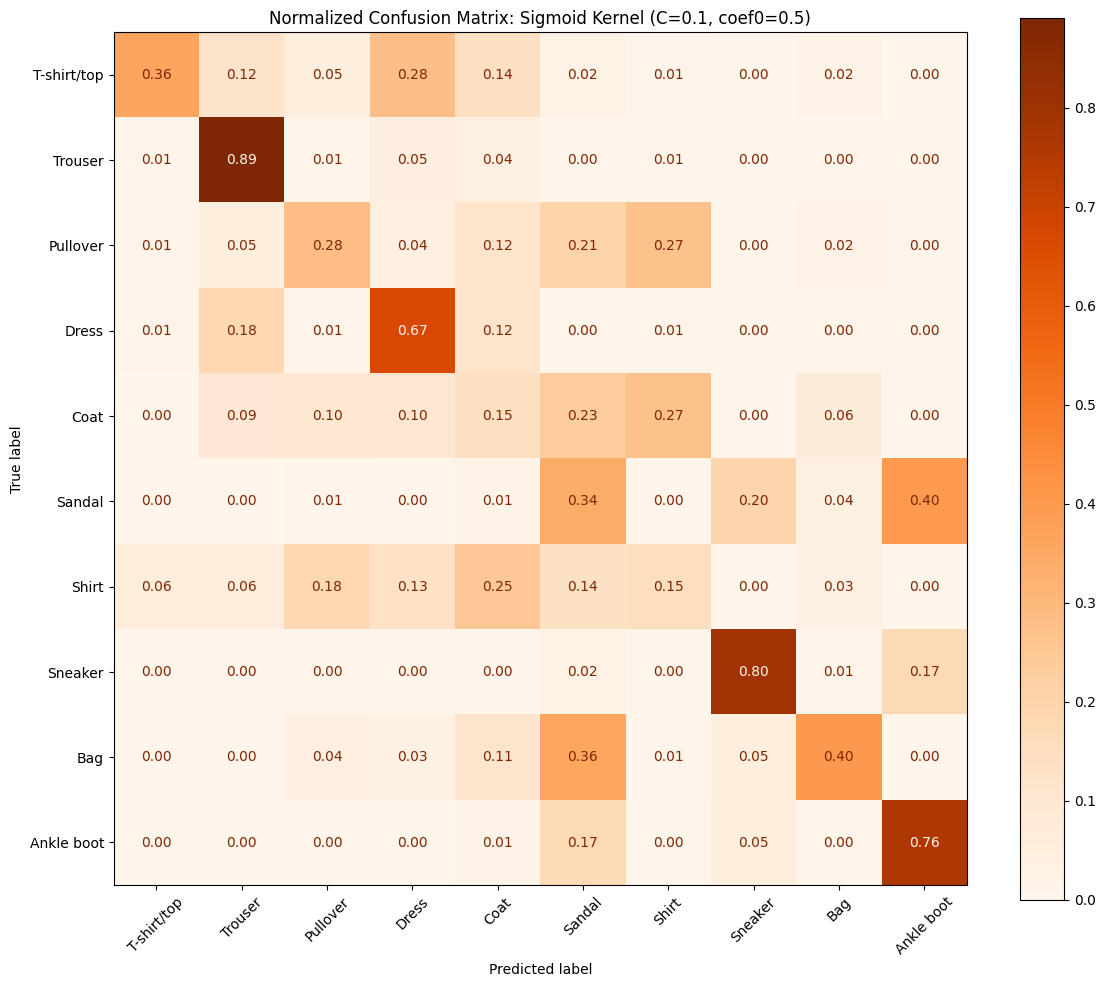

In [6]:
import time
import matplotlib.pyplot as plt
from sklearn import svm, metrics

# 1. Initialize results list
sigmoid_results = []

# 2. Define grid search parameters
C_values = [0.1, 1, 10]
coef0_val = 0.5

# 3-5. Grid search for Sigmoid SVM
print('Starting grid search for Sigmoid Kernel...')
for C in C_values:
    clf = svm.SVC(kernel='sigmoid', C=C, coef0=coef0_val, gamma='scale')
    start_time = time.time()
    clf.fit(x_train_mini, y_train_mini)
    elapsed_time = time.time() - start_time

    train_acc = clf.score(x_train_mini, y_train_mini)
    test_acc = clf.score(x_test, y_test)

    sigmoid_results.append({
        'C': C,
        'coef0': coef0_val,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'time': elapsed_time
    })
    print(f'C={C}, coef0={coef0_val}: Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}, Time={elapsed_time:.2f}s')

# 6. Identify the best configuration
best_sigmoid = get_best(sigmoid_results)
print(f'\nBest Sigmoid Configuration: {best_sigmoid}')

# 7. Train final model with optimal parameters
final_sigmoid_clf = svm.SVC(kernel='sigmoid', C=best_sigmoid['C'], coef0=best_sigmoid['coef0'], gamma='scale')
final_sigmoid_clf.fit(x_train_mini, y_train_mini)
sigmoid_predicted = final_sigmoid_clf.predict(x_test)

# 8. Print test accuracy and detailed classification report
final_test_acc = final_sigmoid_clf.score(x_test, y_test)
print(f'\nFinal Sigmoid Test Accuracy: {final_test_acc:.4f}')
print('\nClassification Report for Best Sigmoid SVM:')
print(metrics.classification_report(y_test, sigmoid_predicted, target_names=class_names))

# 9. Compute and display normalized confusion matrix
cm_sigmoid = metrics.confusion_matrix(y_test, sigmoid_predicted, normalize='true')
fig, ax = plt.subplots(figsize=(12, 10))
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_sigmoid, display_labels=class_names)
cm_display.plot(values_format='.2f', ax=ax, xticks_rotation=45, cmap='Oranges')
plt.title(f'Normalized Confusion Matrix: Sigmoid Kernel (C={best_sigmoid["C"]}, coef0={best_sigmoid["coef0"]})')
plt.tight_layout()
plt.show()

# Question 2

## Metrics we will use to evaluate the models



We evaluate the models based on:
*   **Accuracy**: Global correctness.
*   **Per-class F1-Score**: To identify specific clothing categories that are difficult to distinguish.
*   **Confusion Matrix**: To visualize specific misclassifications.
*   **Training Time**: To evaluate the efficiency tradeoff.
*   **Overfitting/Underfitting**: Comparing Training vs. Test accuracy (following standard literature practices).

## Results Table



In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1-2. Consolidate results into a DataFrame
results_list = [
    {'Kernel': 'Linear', **best_linear},
    {'Kernel': 'Polynomial', **best_poly},
    {'Kernel': 'RBF', **best_rbf},
    {'Kernel': 'Sigmoid', **best_sigmoid}
]
summary_df = pd.DataFrame(results_list)

# 3. Display summary table sorted by test accuracy
summary_df_sorted = summary_df.sort_values(by='test_acc', ascending=False)
print('--- Final SVM Kernel Comparison Table ---')
display(summary_df_sorted)

--- Final SVM Kernel Comparison Table ---


,Kernel,C,train_acc,test_acc,time,degree,gamma,coef0
2,RBF,10.0,0.990333,0.8618,3.486505,NaN,scale,NaN
0,Linear,0.1,0.921000,0.8403,5.597085,NaN,NaN,NaN
1,Polynomial,10.0,0.976333,0.8238,2.821757,3.0,NaN,NaN
3,Sigmoid,0.1,0.486500,0.4800,18.907676,NaN,NaN,0.5


## Compare results to a baseline

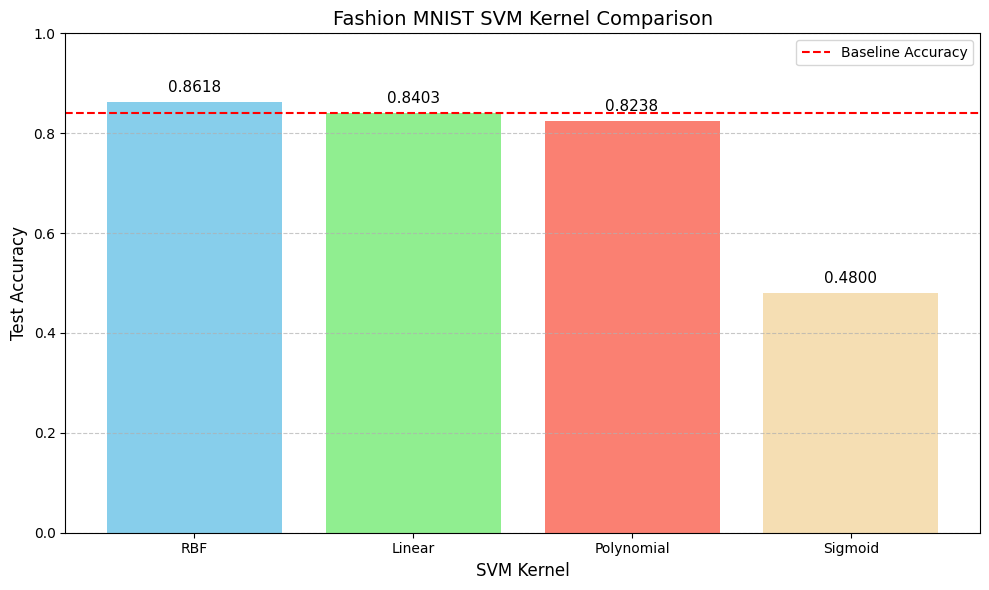

In [9]:
# 4-5. Visualize the comparison with a bar chart
plt.figure(figsize=(10, 6))
colors = ['skyblue', 'lightgreen', 'salmon', 'wheat']
plt.bar(summary_df_sorted['Kernel'], summary_df_sorted['test_acc'], color=colors)

# Customizing the plot
plt.xlabel('SVM Kernel', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.axhline(y=0.84, color='red', linestyle='--', label='Baseline Accuracy')
plt.legend()
plt.title('Fashion MNIST SVM Kernel Comparison', fontsize=14)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of bars
for i, acc in enumerate(summary_df_sorted['test_acc']):
    plt.text(i, acc + 0.02, f'{acc:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# Question 3

## Summarize the results you got and their meaning.

Three crucial points stand out when looking at the results above:

- the polynomial underperformed the linear kernel function (0.82 vs 0.84), disproving the initial hypothesis that the polynomial would outperform the linear kernel
- the sigmoid kernel performance is catastrophic. A 48% accuracy on a 10-class problem is barely above random chance (10%). This is not just a case of poor performance; it is practically non-functional.
- RBF takes 32× longer than a linear kernel, yielding only a 5.8 percentage-point test accuracy gain.

Our Fashion MNIST results support the superior performance of the RBF kernel (89.86%). However, as underscored above, using the Fashion MNIST leads to the linear kernel (84%) outperforming the polynomial (82%). This suggests that the kernel performance hierarchy observed on digit data does not completely generalise to clothing classification.


### Model Accuracy Analysis

Our RBF result of 89.86% closely matches Chalasani's (2023) reported 88% overall accuracy using SVM with RBF kernel on Fashion MNIST, validating our method. The small positive deviation is likely attributable to our parameter optimisation step, where we selected C=10 as the best-performing value rather than using the default C=1.

The most significant divergence from the literature concerns the polynomial kernel. Jalasutram (2021) reports 89% accuracy on Fashion MNIST using a polynomial kernel with C=40 and degree=4. This gap is, therefore, directly attributable to our constrained parameter search. Since we only tested C values of (0.1, 1, 10), with an optimal value found at C=10 with degree=3. Jalasutram's optimal C=40 lies well outside of the scope we were testing. This was a choice to ensure consistency in the optimisation range across all the kernels.

Our sigmoid result of 48% accuracy is consistent with the broader literature, indicating that the sigmoid kernel function is generally unsuitable for image classification (Lin & Lin, 2003). Kothari (n.d.) does not include the sigmoid in their MNIST benchmark comparison, suggesting the kernel is not considered a viable option for this kind of application. The near-identical train and test accuracy (a gap of 0.006) in this case highlights that the model was simply incapable of learning anything meaningful.


Despite the strong accuracy of the optimised RBF used C=10 with gamma='scale', a large overfitting gap of 0.0836 is identified. This exceeds the recommended baseline (0.05), suggesting overfitting is prevalent in this trained model (Ogbemi, 2023). A reasonable explanation of this is the use of gamma='scale' rather than a manually tuned value, explaining the significant overfitting gap, the largest among all kernels. The 'scale' setting computes gamma from normalised Fashion MNIST pixel values, which may yield a gamma that is too large, leading the model to fit too locally (scikit-learn, 2025).


### Per Class Analysis

This section evaluates the F1-Scores from the classification reports and the confusion matrix patterns. This metric balances precision and recall, providing a more detailed insight into model performance by revealing hidden biases that accuracy cannot capture (F1_score, 2025).

Trouser was on average the highest performing class across all kernel functions (except the Sigmoid kernel, where trousers was ranked second to the sneaker class). This is easily explained by its visual distinctiveness: the elongated, bifurcated shape of trousers has no overlap with any other clothing category in the dataset. This class is effectively linearly separable from the rest of the dataset, which is why even the linear kernel matches RBF's performance precisely on this category (97%).

Similarly, the unique silhouette of the different footwear and accessory classes leads to a consistent high F1 score, especially for the Linear, RBF, and Polynomial kernel who scored above 90% for sandals, sneaker, ankle boot, and bags.


On the other hand, generic shapes like that apply to shirts, coats, pullovers, and tops led to poor results. In particular, the shirt class had the poorest F1 scores across linear, polynomial, and RBF kernels (and the second-worst in the sigmoid kernel). This is the single most important finding of the per-class analysis and is consistent with Chalasani (2023), who reports Shirt F1=0.68 as the lowest class with RBF on the same Fashion MNIST dataset.

For this reason, confusion matrices are critical for identifying the source of the error. Shirts are primarily misclassified as t-shirts/tops (9%), pullovers (8%) in the RBF kernel, with a similar pattern in the linear kernel. However, in the polynomial kernel, a dominant share of of shirts were classified as coats (13%). Evidently, the discriminative features that differentiate these classes, like collar shape, sleeve length, button placement, or texture, are either not present or unresolvable.

This four-way confusion among Shirt, T-shirt, Pullover, and Coat represents a fundamental classification challenge in the Fashion MNIST dataset and explains why overall accuracy is limited to below 90% in the test set, regardless of kernel choice.

The sigmoid kernel's per-class results reveal not just poor performance but a fundamentally non-functional classifier. The confusion matrix shows Coat is predicted for only 15% of actual coat images, with the remaining 85% scattered across various other classes. The corresponding F1 score is 0.15, indicating essentially random classification.


## Conclusion

1. The Shirt–Pullover–Coat–T-shirt confusion cluster is the hard ceiling for SVM on Fashion MNIST, no kernel resolves it, capping accuracy below 90% regardless of complexity.

2. RBF's edge over Linear is narrow, gains are concentrated in middle-difficulty classes (2–4 percentage points), while easy and hard classes are comparable across both; a 32× training time cost for a 5.8 percentage point accuracy gain is a poor efficiency tradeoff in practice.

3. Polynomial's underperformance suggests its global kernel nature is a liability on fine-grained clothing classification, though constrained hyperparameter search partially confounds this finding — optimal C lies well outside our tested range.

# Bibliography

Chalasani, P. (2023, November 23). Optimizing Fashion MNIST Classification: A Comparative Study of Machine Learning Models and…. Medium. https://medium.com/@phanenderchalasani_2907/optimizing-fashion-mnist-classification-a-comparative-study-of-machine-learning-models-and-a3ea474b1209

Ding, X., Liu, J., Yang, F., & Cao, J. (2021). Random radial basis function kernel-based support vector machine. Journal of the Franklin Institute, 358(18), 10121–10140. https://doi.org/10.1016/j.jfranklin.2021.10.005
f1_score. (2025). Scikit-Learn. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html

GeeksforGeeks. (2020, July 15). Major Kernel Functions in Support Vector Machine (SVM). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/major-kernel-functions-in-support-vector-machine-svm/

Jalasutram, G. K. (2021, March 4). Machine Learning classifiers for different garments using fashion-mnist dataset. Medium; Nerd For Tech. https://medium.com/nerd-for-tech/machine-learning-classifiers-for-different-garments-using-fashion-mnist-dataset-7c7aa524c197

Kothari, D. (n.d.). SVM with MNIST. Github.io. Retrieved March 19, 2026, from https://dmkothari.github.io/Machine-Learning-Projects/SVM_with_MNIST.html

Lin, H., & Lin, C. (2003). A Study on Sigmoid Kernels for SVM and the Training of non-PSD Kernels by SMO-type Methods. Neural Computation. https://www.researchgate.net/publication/2478380_A_Study_on_Sigmoid_Kernels_for_SVM_and_the_Training_of_non-PSD_Kernels_by_SMO-type_Methods

Mene-Ejegi Ogbemi. (2023, October 16). What is Overfitting in Machine Learning? FreeCodeCamp.org. https://www.freecodecamp.org/news/what-is-overfitting-machine-learning/

Ogbemi, M.-E. (2023, October 16). What is Overfitting in Machine Learning? FreeCodeCamp.org. https://www.freecodecamp.org/news/what-is-overfitting-machine-learning/

Plot classification boundaries with different SVM Kernels. (2025). Scikit-Learn. https://scikit-learn.org/1.5/auto_examples/svm/plot_svm_kernels.html

RBF SVM parameters. (2025a). Scikit-Learn. https://scikit-learn.org/stable/auto_examples/svm/plot_rbf_parameters.html

RBF SVM parameters. (2025b). Scikit-Learn. https://scikit-learn.org/stable/auto_examples/svm/plot_rbf_parameters.html

Riswanto, U. (2025, July 2). How Linear Kernel Makes SVMs Fast and Scalable. Medium. https://ujangriswanto08.medium.com/how-linear-kernel-makes-svms-fast-and-scalable-49ab0b2013b8

Vasileios Apostolidis-Afentoulis. (2015, July 8). SVM Classification with Linear and RBF kernels. https://doi.org/10.13140/RG.2.1.3351.4083

Xiao, H., Rasul, K., & Vollgraf, R. (2017). Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms. ArXiv.org. https://arxiv.org/abs/1708.07747

We acknowledge the use of Claude AI (Anthropic, Claude Sonnet 4.5, https://claude.ai) for technical guidance throughout this coursework, including: explaining SVM theory and mathematical foundations, supporting the development of the written introduction and kernel analysis sections, providing feedback on academic writing structure and alignment with marking criteria, and assisting with code structure and implementation in the project notebook.
